In [6]:
import vitaldb
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [7]:
vf = vitaldb.VitalFile("ICU.vital") #load
print(vf.get_track_names()) #check

['Intellivue/ABP_MEAN', 'Intellivue/ABP_SYS', 'Intellivue/ABP_DIA', 'Intellivue/ABP_HR', 'Intellivue/CVP_MEAN', 'Intellivue/PLETH_SAT_O2', 'Intellivue/PLETH_HR', 'Intellivue/PLETH_PERF_REL', 'Intellivue/NIBP_SYS', 'Intellivue/NIBP_DIA', 'Intellivue/NIBP_MEAN', 'Intellivue/NIBP_HR', 'Intellivue/ECG_HR', 'Intellivue/RR', 'Intellivue/ST_II', 'Intellivue/ECG_VPC_CNT', 'Intellivue/QT_GL', 'Intellivue/QTc', 'Intellivue/QTc_DELTA', 'Intellivue/QT_HR', 'Intellivue/ABP', 'Intellivue/CVP', 'Intellivue/ECG_II', 'Intellivue/PLETH']


In [8]:
#Fs check
for track_name, track in vf.trks.items():
    print(f"{track_name:40s} | {track.srate} Hz")

Intellivue/ABP_MEAN                      | 1.0 Hz
Intellivue/ABP_SYS                       | 1.0 Hz
Intellivue/ABP_DIA                       | 1.0 Hz
Intellivue/ABP_HR                        | 1.0 Hz
Intellivue/CVP_MEAN                      | 1.0 Hz
Intellivue/PLETH_SAT_O2                  | 1.0 Hz
Intellivue/PLETH_HR                      | 1.0 Hz
Intellivue/PLETH_PERF_REL                | 1.0 Hz
Intellivue/NIBP_SYS                      | 1.0 Hz
Intellivue/NIBP_DIA                      | 1.0 Hz
Intellivue/NIBP_MEAN                     | 1.0 Hz
Intellivue/NIBP_HR                       | 1.0 Hz
Intellivue/ECG_HR                        | 1.0 Hz
Intellivue/RR                            | 1.0 Hz
Intellivue/ST_II                         | 1.0 Hz
Intellivue/ECG_VPC_CNT                   | 1.0 Hz
Intellivue/QT_GL                         | 1.0 Hz
Intellivue/QTc                           | 1.0 Hz
Intellivue/QTc_DELTA                     | 1.0 Hz
Intellivue/QT_HR                         | 1.0 Hz


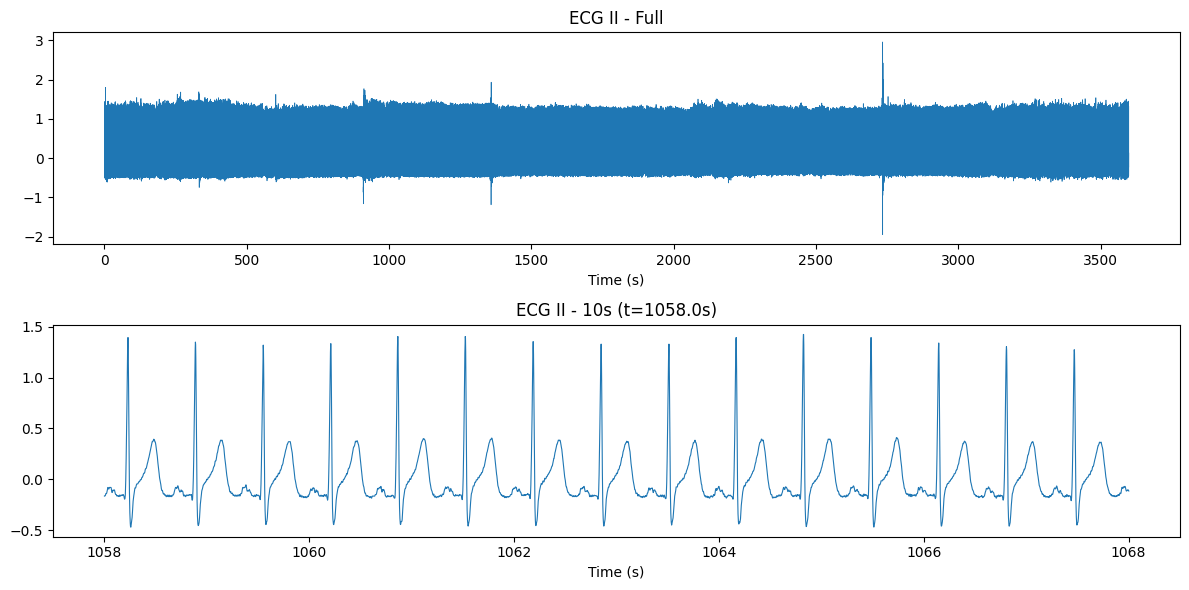

In [15]:
import random
import matplotlib.pyplot as plt

total_sec = len(ecg_data) / 500
start_sec = random.uniform(0, total_sec - 10)
start_idx = int(start_sec * 500)
end_idx   = start_idx + 10 * 500

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_ecg, ecg_data[:, 0], linewidth=0.5)
axes[0].set_title('ECG II - Full')
axes[0].set_xlabel('Time (s)')

axes[1].plot(t_ecg[start_idx:end_idx], ecg_data[start_idx:end_idx, 0], linewidth=0.8)
axes[1].set_title(f'ECG II - 10s (t={start_sec:.1f}s)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [ ]:
# ── ABP, CVP, PLETH (125Hz) ───────────────────────────────────
fig_wave = make_subplots(rows=3, cols=1, shared_xaxes=True,
                         subplot_titles=['ABP', 'CVP', 'PLETH'],
                         vertical_spacing=0.05)
for i, (name, color_idx) in enumerate([('ABP', 0), ('CVP', 1), ('PLETH', 2)], start=1):
    fig_wave.add_trace(
        go.Scattergl(x=t_125, y=wave125[:, color_idx], mode='lines', name=name,
                     line=dict(width=0.8), connectgaps=False),
        row=i, col=1
    )
fig_wave.update_layout(height=600, title="Waveforms 125Hz", hovermode='x unified', dragmode='zoom')
fig_wave.update_xaxes(title_text="Time (s)", row=3, col=1, zeroline=False)
fig_wave.update_yaxes(zeroline=False)
fig_wave.write_html("waveform.html", include_plotlyjs='cdn')

In [ ]:
# ── Figure 2: Numeric Parameters (1Hz) ───────────────────────
groups = {
    'BP (mmHg)':  ['Intellivue/ABP_SYS', 'Intellivue/ABP_MEAN', 'Intellivue/ABP_DIA',
                   'Intellivue/NIBP_SYS', 'Intellivue/NIBP_MEAN', 'Intellivue/NIBP_DIA'],
    'HR (bpm)':   ['Intellivue/ABP_HR', 'Intellivue/PLETH_HR', 'Intellivue/ECG_HR'],
    'SpO2 / CVP': ['Intellivue/PLETH_SAT_O2', 'Intellivue/CVP_MEAN'],
    'RR / ST_II': ['Intellivue/RR', 'Intellivue/ST_II'],
}

fig2 = make_subplots(
    rows=len(groups), cols=1,
    shared_xaxes=True,
    subplot_titles=list(groups.keys()),
    vertical_spacing=0.06
)

for row_i, (group_name, tracks) in enumerate(groups.items(), start=1):
    for track in tracks:
        if track in numeric_tracks:
            idx = numeric_tracks.index(track)
            fig2.add_trace(
                go.Scatter(x=t_num, y=num_data[:, idx],
                           mode='lines', name=track.split('/')[-1],
                           connectgaps=False),
                row=row_i, col=1
            )

fig2.update_layout(
    height=800, title="Numeric Parameters (1Hz)",
    hovermode='x unified', dragmode='zoom',
)
fig2.update_xaxes(zeroline=False)
fig2.update_yaxes(zeroline=False)
fig2.update_xaxes(title_text="Time (s)", row=len(groups), col=1)
fig2.write_html("numeric.html")